In [3]:
import librosa
import numpy as np
import matplotlib.pyplot as plt 
import scipy
from IPython.display import Audio, display
from scipy.signal import find_peaks
import os
import soundfile as sf

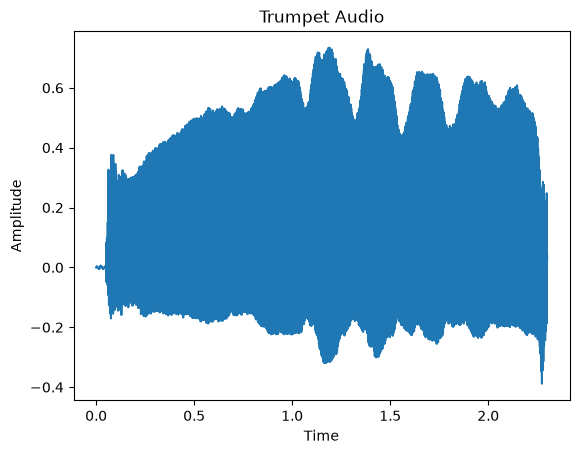

In [4]:
x, sr = librosa.load('/Users/jonathan/soundwall_project/timbreframe/assets/trumpet_eb.mp3', sr = None)
x = x[1146600:1146600+int(sr*2.3)]
n_fft = 4096
hop_length = 1024
freq_res = sr / n_fft
time = len(x)/sr #time in seconds
plt.plot(np.linspace(0, time, len(x)), x)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Trumpet Audio')
plt.show()


In [5]:
sr *2.5

110250.0

In [6]:
Audio(x, rate=sr)

In [7]:
sf.write("chopped_trumpet.wav", x, sr)

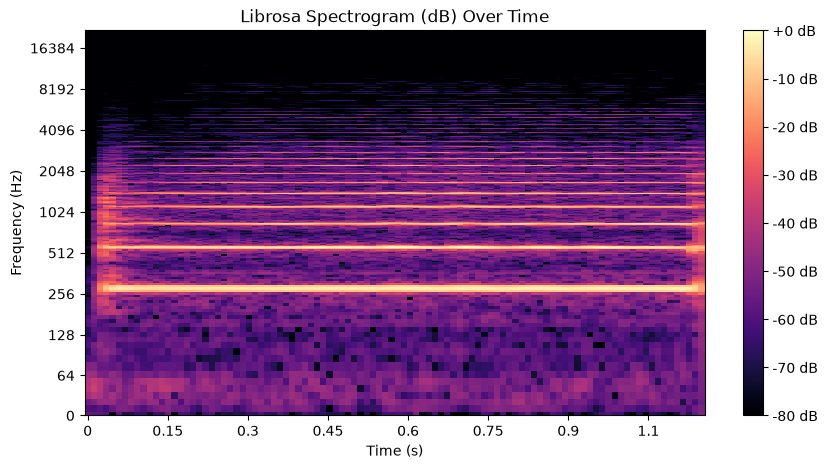

In [8]:
X = librosa.stft(x, n_fft=4096, hop_length=1024)
mag = np.abs(X)
X_db = librosa.amplitude_to_db(mag, ref=np.max)

plt.figure(figsize=(10, 5))
librosa.display.specshow(X_db, sr=sr, x_axis='time', y_axis='log', cmap='magma')

plt.title('Librosa Spectrogram (dB) Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, sr/2)
plt.show()

In [27]:
mag_mean = np.mean(mag, axis=1) ####Taking the mean of the magnitude across the time axis
print(mag_mean.shape)
# peaks, _ = find_peaks(mag_mean, distance=10, prominence=np.max(mag_mean)*0.001) ####frequency bins
peaks = librosa.util.peak_pick(mag_mean, pre_max=2, post_max=2, pre_avg=7, post_avg=7, delta=0.0001 *np.max(mag_mean), wait=0)
####trying librosa method for peak detection
print(f"Peaks: {peaks}, number of peaks: {peaks.shape[0]}")

if peaks.shape[0] > 24: ###maintains 24 peaks
    peaks = peaks[:24] 
print(f"Peaks: {peaks}, number of peaks: {peaks.shape[0]}")


peak_to_hz = peaks *freq_res #converting peak indices to frequencies
print(f"Peak frequencies: {peak_to_hz}, number of peaks: {peak_to_hz.shape[0]}")
freq_mag_mean= mag_mean[peaks] ####Getting the mean magnitude at the peak frequencies
print(f"Mean magnitudes at peak frequencies: {freq_mag_mean}, number of peaks: {freq_mag_mean.shape[0]}")
# freq_mag_mean.shape #23
# peak_to_hz.shape #23
# peak_to_hz
# freq_mag_mean.shape

(2049,)
Peaks: [  5  15  26  52  78  89  92 104 120 130 147 156 173 182 198 209 234 260
 276 287 313 325 338 364 391 417 443 469 494 521 545 547 574 597 599 624
 627 650 652 678 702 729 757 835], number of peaks: 44
Peaks: [  5  15  26  52  78  89  92 104 120 130 147 156 173 182 198 209 234 260
 276 287 313 325 338 364], number of peaks: 24
Peak frequencies: [  53.83300781  161.49902344  279.93164062  559.86328125  839.79492188
  958.22753906  990.52734375 1119.7265625  1291.9921875  1399.65820312
 1582.69042969 1679.58984375 1862.62207031 1959.52148438 2131.78710938
 2250.21972656 2519.38476562 2799.31640625 2971.58203125 3090.01464844
 3369.94628906 3499.14550781 3639.11132812 3919.04296875], number of peaks: 24
Mean magnitudes at peak frequencies: [8.74768317e-01 4.93288815e-01 1.48243881e+02 1.47283478e+02
 8.52103119e+01 8.91095579e-01 9.11426187e-01 6.11711655e+01
 1.42487717e+00 5.72794380e+01 5.58028460e-01 2.38954086e+01
 5.81827521e-01 1.24351845e+01 3.42335522e-01 1.64448071

In [28]:
def create_adsr_envelope(duration, sr, attack_time=0.5, decay_time=0.3, release_time=0.2, sustain_level=0.7):
    t = np.arange(0, duration, 1/sr)
    total_samples = len(t)

    # Convert times to sample counts
    attack_samples = int(attack_time * sr)
    decay_samples = int(decay_time * sr)
    release_samples = int(release_time * sr)
    sustain_samples = total_samples - (attack_samples + decay_samples + release_samples)
    
    # 1. Attack: Linear ramp from 0.0 to 1.0
    attack = np.linspace(0.0, 1.0, attack_samples)
    
    # 2. Decay: Linear ramp from 1.0 down to sustain level
    decay = np.linspace(1.0, sustain_level, decay_samples)
    
    # 3. Sustain: Constant level
    sustain = np.ones(sustain_samples) * sustain_level
    
    # 4. Release: Linear ramp from sustain level down to 0.0
    release = np.linspace(sustain_level, 0.0, release_samples)
    
    # Concatenate all stages together into one continuous envelope
    envelope = np.concatenate([attack, decay, sustain, release])
    
    # If there's a minor rounding error in sample length, pad or trim to match 't' exactly
    if len(envelope) < total_samples:
        envelope = np.pad(envelope, (0, total_samples - len(envelope)), 'constant')
    elif len(envelope) > total_samples:
        envelope = envelope[:total_samples]
        
    return envelope

In [29]:
def create_vibrato_envelope(duration, sr,vibrato_attack_time):
    t = np.arange(0, duration, 1/sr)
    total_samples = len(t)
    
    # Vibrato takes 1.5 seconds to reach full intensity
    attack_samples = int(vibrato_attack_time * sr)
    sustain_samples = total_samples - attack_samples
    
    # Fade in from 0.0 (no vibrato) to 1.0 (full vibrato)
    vib_attack = np.linspace(0.0, 1.0, attack_samples)
    vib_sustain = np.ones(sustain_samples)
    
    vib_envelope = np.concatenate([vib_attack, vib_sustain])
    return vib_envelope

In [30]:
def generate_sine_waves():
    t = np.arange(0,8, 1/sr)
    y = np.zeros(len(t))
    mono_audio = np.zeros(len(t)) #to store mono audio
    multichannel_audio = np.zeros((len(peak_to_hz), len(t))) # to store multichannel audio
    vib_freq = 3
    vib_mag = 0.05
    am_freq = 5
    am_depth = 0.065
    fund_freq = peak_to_hz[0]
    base_attack = 0.01
    base_decay = 0.4
    base_release = 0.15
    base_sustain = 0.8
    duration = 8
    vib_envelope = create_vibrato_envelope(duration=8, sr=sr, vibrato_attack_time=3)
    attack_per_partial = 0.002

    # mag_envelope = create_adsr_envelope(duration=8, sr=sr, attack_time=base_attack, decay_time=base_decay, release_time=base_release, sustain_level=base_sustain)

    for i in range(len(peak_to_hz)):
        freqs = peak_to_hz[i]
        magnitude = freq_mag_mean[i]
        harm_rank = freqs / fund_freq


        # --- DYNAMIC TRUMPET EMBELLISHMENTS ---
        # 1. Sequential Attack: Stagger the attack slightly based on the harmonic rank
        # Higher harmonics take a few milliseconds longer to fully blow open
        channel_attack = base_attack + (attack_per_partial * (harm_rank - 1))
        
        # 2. Decay Drop: High harmonics drop radically lower during sustain
        # Scaling factor pushes high rank sustains down aggressively (clamped to a minimum of 0.05)
        channel_sustain = max(base_sustain * np.exp(-0.15 * (harm_rank - 1)), 0.1)
        
        # Generate a customized unique ADSR envelope for THIS specific channel
        channel_mag_envelope = create_adsr_envelope(
            duration=duration, 
            sr=sr, 
            attack_time=channel_attack, 
            decay_time=base_decay, 
            release_time=base_release, 
            sustain_level=channel_sustain
        )


        ###unique phase shift for each harmonic
        random_phase_offset = np.random.rand() * 2 * np.pi
        scaled_am_freq = am_freq + (0.1 * harm_rank)



        ###modulate the magnitude
        mag_modulation = am_depth*np.sin(2 * np.pi * scaled_am_freq * t +random_phase_offset)
        subtle_mag_mod = magnitude * (1 + mag_modulation)
        scaled_vib_magnitude = vib_mag * harm_rank * vib_envelope

        ###synthesize partial
        channel_wave = subtle_mag_mod *np.sin(2 * np.pi *  freqs * t +scaled_vib_magnitude * np.sin(2 * np.pi * vib_freq * t))
        ###apply magnitude envelope
        channel_wave_enveloped = channel_wave * channel_mag_envelope
        ##add that to the multichannel audio
        multichannel_audio[i, :] = channel_wave_enveloped
        ###add raw enveloped track to the mono audio
        y += channel_wave_enveloped 
    global_max = np.max(np.abs(multichannel_audio))
    if global_max > 0:
        # Scale the entire matrix by this single number. 
        # The loudest track becomes 0.5, and the quietest track stays perfectly proportional!
        multichannel_audio = (multichannel_audio / global_max) * 0.5

    # --- PRINT THE MAGNITUDES HERE ---
    print("--- Normalized Peak Magnitudes per Channel ---")
    for i in range(len(peak_to_hz)):
        channel_peak = np.max(np.abs(multichannel_audio[i, :]))
        print(f"Channel {i+1:02d} ({int(peak_to_hz[i])} Hz): Peak Amp = {channel_peak:.5f}")
    print("-----------------------------------------------\n")


    # STEP 3: Mono Mix Normalization
    # Since y was built from proportional raw waves, we just normalize it cleanly at the end
    if np.max(np.abs(y)) > 0:
        mono_audio = (y / np.max(np.abs(y))) * 0.5
    else:
        mono_audio = y


    
    return  multichannel_audio, mono_audio
multichannel_audio, mono = generate_sine_waves()
Audio(mono, rate=sr, normalize=False) ###generate multichannel audio

--- Normalized Peak Magnitudes per Channel ---
Channel 01 (53 Hz): Peak Amp = 0.00288
Channel 02 (161 Hz): Peak Amp = 0.00168
Channel 03 (279 Hz): Peak Amp = 0.50000
Channel 04 (559 Hz): Peak Amp = 0.46475
Channel 05 (839 Hz): Peak Amp = 0.28444
Channel 06 (958 Hz): Peak Amp = 0.00278
Channel 07 (990 Hz): Peak Amp = 0.00322
Channel 08 (1119 Hz): Peak Amp = 0.19203
Channel 09 (1291 Hz): Peak Amp = 0.00448
Channel 10 (1399 Hz): Peak Amp = 0.18546
Channel 11 (1582 Hz): Peak Amp = 0.00197
Channel 12 (1679 Hz): Peak Amp = 0.07475
Channel 13 (1862 Hz): Peak Amp = 0.00201
Channel 14 (1959 Hz): Peak Amp = 0.03908
Channel 15 (2131 Hz): Peak Amp = 0.00116
Channel 16 (2250 Hz): Peak Amp = 0.05766
Channel 17 (2519 Hz): Peak Amp = 0.04042
Channel 18 (2799 Hz): Peak Amp = 0.02402
Channel 19 (2971 Hz): Peak Amp = 0.00050
Channel 20 (3090 Hz): Peak Amp = 0.00901
Channel 21 (3369 Hz): Peak Amp = 0.00396
Channel 22 (3499 Hz): Peak Amp = 0.00029
Channel 23 (3639 Hz): Peak Amp = 0.00112
Channel 24 (3919 H

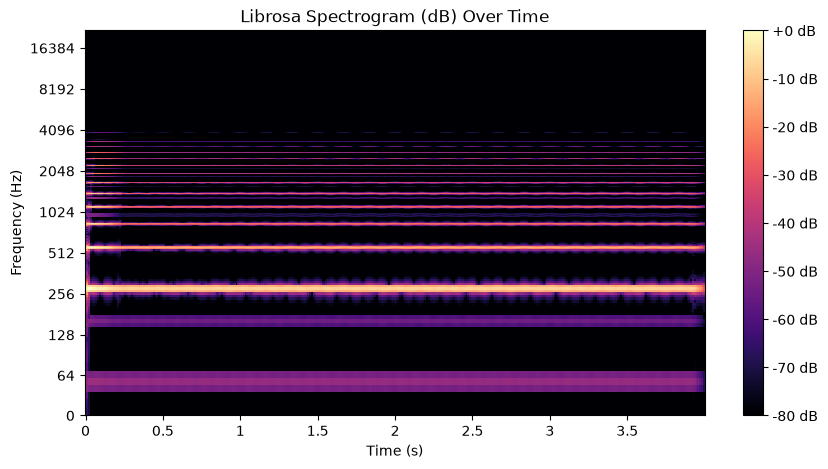

In [31]:
mono_fft = librosa.stft(mono, n_fft=4096, hop_length=1024)
mag = np.abs(mono_fft)
mono_fft_db = librosa.amplitude_to_db(mag, ref=np.max)

plt.figure(figsize=(10, 5))
librosa.display.specshow(mono_fft_db, sr=sr, x_axis='time', y_axis='log', cmap='magma')

plt.title('Librosa Spectrogram (dB) Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, sr/2)
plt.show()

In [80]:


def export_audio_channels(multichannel_audio, peak_to_hz, sr, output_dir="trumpet_partials"):
    os.makedirs(output_dir, exist_ok=True)
    num_partials = multichannel_audio.shape[0]
    
    print("Exporting individual mono tracks...")
    for i in range(num_partials):
        freqs = peak_to_hz[i]
        channel_wave = multichannel_audio[i, :]
        
        # Save individual file
        filename = f"harmonic_{i+1:02d}_{int(freqs)}Hz.wav"
        filepath = os.path.join(output_dir, filename)
        sf.write(filepath, channel_wave, sr)
        
    # Soundfile expects files in (samples, channels) shape, so we transpose (.T)
    master_multichannel = multichannel_audio.T
    
    master_path = "clarinet_23_channels.wav"
    sf.write(master_path, master_multichannel, sr)
    print(f"Export complete! Multi-channel file saved as '{master_path}'")

In [81]:
export_audio_channels(multichannel_audio, peak_to_hz, sr)

Exporting individual mono tracks...
Export complete! Multi-channel file saved as 'clarinet_23_channels.wav'


In [69]:
# =====================================================================
# MACRO CONFIGURATION TEST WORKBENCH
# =====================================================================

# 1. DIAL IN YOUR SETTINGS HERE TO TEST
test_config = {
    "sr": sr,                     # Uses your notebook's sample rate variable
    "duration": 5.0,
    "vibrato_freq": 4.0,          # Try changing to 6.5 for a faster violin vibrato
    "vibrato_mag": 0.03,          # Set to 0.0 for plucked instruments
    "vibrato_attack_time": 4.0,   # How long until full vibrato kicks in
    "am_freq": 5.0,
    "am_depth": 0.065,            # Try 0.15 for heavy tremolo / breath flutter
    "attack_time": 0.01,           # Set to 0.01 for an instant guitar pluck
    "decay_time": 0.6,
    "sustain_level": 0.8,
    "release_time": 0.3
}

# 2. RUN SYNTHESIS LOOP USING COPIED MATH
t = np.arange(0, test_config["duration"], 1 / test_config["sr"])
y_test = np.zeros(len(t))
fund_freq = peak_to_hz[0]

# Generate envelopes based on your test config
vib_env = create_vibrato_envelope(test_config["duration"], test_config["sr"], test_config["vibrato_attack_time"])
mag_env = create_adsr_envelope(test_config["duration"], test_config["sr"], 
                               test_config["attack_time"], test_config["decay_time"], 
                               test_config["release_time"], test_config["sustain_level"])

for i in range(len(peak_to_hz)):
    freqs = peak_to_hz[i]
    magnitude = freq_mag_mean[i]
    harm_rank = freqs / fund_freq
    
    random_phase_offset = np.random.rand() * 2 * np.pi
    scaled_am_freq = test_config["am_freq"] + (0.1 * harm_rank)
    
    # Apply modulations using config values
    mag_modulation = test_config["am_depth"] * np.sin(2 * np.pi * scaled_am_freq * t + random_phase_offset)
    subtle_mag_mod = magnitude * (1 + mag_modulation)
    scaled_vib_magnitude = test_config["vibrato_mag"] * harm_rank * vib_env
    
    channel_wave = subtle_mag_mod * np.sin(2 * np.pi * freqs * t + scaled_vib_magnitude * np.sin(2 * np.pi * test_config["vibrato_freq"] * t))
    y_test += channel_wave * mag_env

# Normalize the test audio so it doesn't clip your speakers
if np.max(np.abs(y_test)) > 0:
    y_test = (y_test / np.max(np.abs(y_test))) * 0.5

# 3. LISTEN TO THE RESULT IMMEDIATELY
print(f"Playing test audio with: Attack={test_config['attack_time']}s, Vibrato Mag={test_config['vibrato_mag']}")
Audio(y_test, rate=test_config["sr"], normalize=False)

Playing test audio with: Attack=0.01s, Vibrato Mag=0.03


In [23]:
def wavelength(speaker_diameter_inch,frequency, speed_of_sound=343):
    """ calculate the wavelength of a sound wave given its frequency and the speed of sound,
    as well as the threshold bend frequency for the speaker diameter.
    Larger speaker cones will enable a lower threshold bend frequency, meaning more directional sound with less diffraction.
    """
    speaker_diameter = speaker_diameter_inch * 0.0254  # convert inches to meters
    wavelength = speed_of_sound / frequency
    threshold_bend_frequency = (speed_of_sound / (2 * speaker_diameter)) if speaker_diameter > 0 else 0

    return print(f"Wavelength of {frequency} Hz: {wavelength} meters, Threshold Bend Frequency: {threshold_bend_frequency}")

wavelength(3, 129)


Wavelength of 129 Hz: 2.6589147286821704 meters, Threshold Bend Frequency: 2250.656167979003
